# Lab 2: Classification Using KNN and RNN Algorithms

**Name:** Kshitiz
**Course:** Advanced Big Data and Data Mining (MSCS-634-B01) — Second Bi-term
**Assignment:** Lab 2 — Classification Using KNN and RNN Algorithms

## Overview

In this lab, we explore the performance of **K-Nearest Neighbors (KNN)** and **Radius Neighbors (RNN)** classifiers using the Wine dataset from `sklearn`. The dataset consists of three classes of wine described by various chemical properties. We evaluate how different parameter choices (`k` for KNN, `radius` for RNN) affect classification accuracy, visualize the trends, and compare the two approaches.

## Step 1: Load and Prepare the Dataset

In [ ]:
#Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

In [ ]:
#Load the Wine dataset
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print("Dataset shape:", X.shape)
print("Feature names:", feature_names)
print("Target classes:", target_names)
df.head()

Dataset shape: (178, 13)
Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Target classes: ['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### Basic Data Exploration

In [ ]:
#Summary statistics
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


Class distribution:
  Class 0 (class_0): 59 samples
  Class 1 (class_1): 71 samples
  Class 2 (class_2): 48 samples


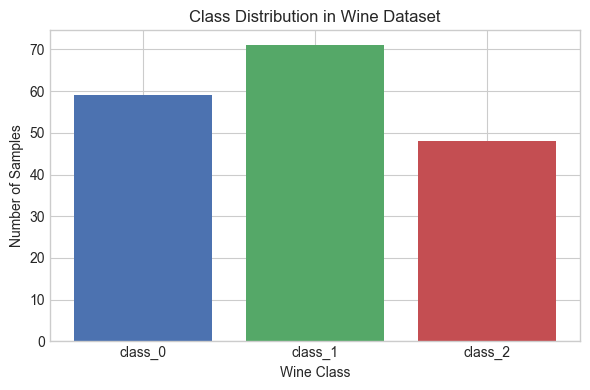

In [ ]:
#Class distribution
class_counts = df['target'].value_counts().sort_index()
print("Class distribution:")
for idx, count in class_counts.items():
    print(f"  Class {idx} ({target_names[idx]}): {count} samples")

plt.figure(figsize=(6, 4))
plt.bar([target_names[i] for i in class_counts.index], class_counts.values, color=['#4C72B0', '#55A868', '#C44E52'])
plt.title('Class Distribution in Wine Dataset')
plt.xlabel('Wine Class')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()

In [ ]:
#Check for missing values
print("Missing values per feature:")
print(df.isnull().sum())

Missing values per feature:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64


### Train/Test Split

We split the dataset into 80% training and 20% testing sets. Since KNN and RNN are distance-based algorithms, we also scale the features using `StandardScaler` so that features with larger numeric ranges (e.g., `proline`) do not dominate the distance calculations.

In [ ]:
#Split into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

#Scale features (important for distance-based algorithms like KNN/RNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train_scaled.shape)
print("Testing set size:", X_test_scaled.shape)

Training set size: (142, 13)
Testing set size: (36, 13)


## Step 2: Implement K-Nearest Neighbors (KNN)

We train KNN classifiers with `k` values of 1, 5, 11, 15, and 21, and record the accuracy on the test set for each.

In [ ]:
#KNN with different k values
k_values = [1, 5, 11, 15, 21]
knn_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    knn_accuracies.append(acc)
    print(f"k = {k:>2} -> Accuracy: {acc:.4f}")

k =  1 -> Accuracy: 0.9722
k =  5 -> Accuracy: 0.9722
k = 11 -> Accuracy: 1.0000
k = 15 -> Accuracy: 1.0000
k = 21 -> Accuracy: 1.0000


In [ ]:
#Summarize KNN results in a table
knn_results = pd.DataFrame({'k': k_values, 'Accuracy': knn_accuracies})
knn_results

,k,Accuracy
0,1,0.972222
1,5,0.972222
2,11,1.000000
3,15,1.000000
4,21,1.000000


## Step 3: Implement Radius Neighbors (RNN)

We train Radius Neighbors classifiers with radius values of 350, 400, 450, 500, 550, and 600, and record the accuracy on the test set for each.

Note: Because RNN can fail to find any neighbors within a small radius for some test points (raising an error), we use `outlier_label='most_frequent'` so that such points are assigned the most frequent class instead of causing the model to fail.

In [ ]:
#RNN with different radius values
radius_values = [350, 400, 450, 500, 550, 600]
rnn_accuracies = []

for r in radius_values:
    rnn = RadiusNeighborsClassifier(radius=r, outlier_label='most_frequent')
    rnn.fit(X_train_scaled, y_train)
    y_pred = rnn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    rnn_accuracies.append(acc)
    print(f"radius = {r:>3} -> Accuracy: {acc:.4f}")

radius = 350 -> Accuracy: 0.3889
radius = 400 -> Accuracy: 0.3889
radius = 450 -> Accuracy: 0.3889
radius = 500 -> Accuracy: 0.3889
radius = 550 -> Accuracy: 0.3889
radius = 600 -> Accuracy: 0.3889


In [ ]:
#Summarize RNN results in a table
rnn_results = pd.DataFrame({'radius': radius_values, 'Accuracy': rnn_accuracies})
rnn_results

,radius,Accuracy
0,350,0.388889
1,400,0.388889
2,450,0.388889
3,500,0.388889
4,550,0.388889
5,600,0.388889


## Step 4: Visualize and Compare Results

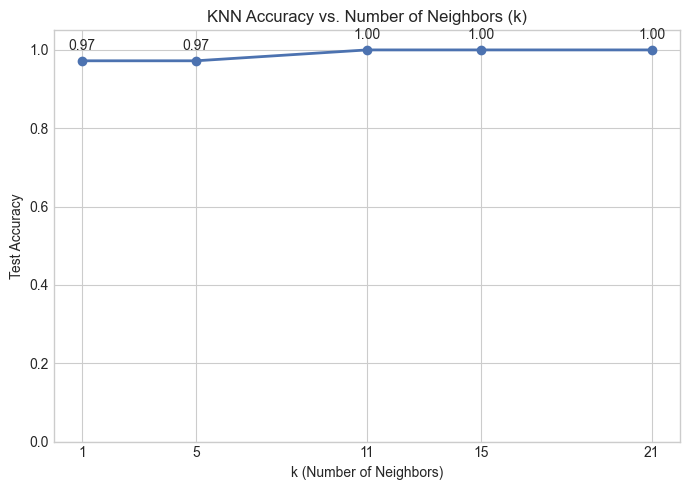

In [ ]:
#Plot KNN accuracy trend
plt.figure(figsize=(7, 5))
plt.plot(k_values, knn_accuracies, marker='o', color='#4C72B0', linewidth=2)
plt.title('KNN Accuracy vs. Number of Neighbors (k)')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Test Accuracy')
plt.xticks(k_values)
plt.ylim(0, 1.05)
for k, acc in zip(k_values, knn_accuracies):
    plt.annotate(f"{acc:.2f}", (k, acc), textcoords="offset points", xytext=(0, 8), ha='center')
plt.tight_layout()
plt.show()

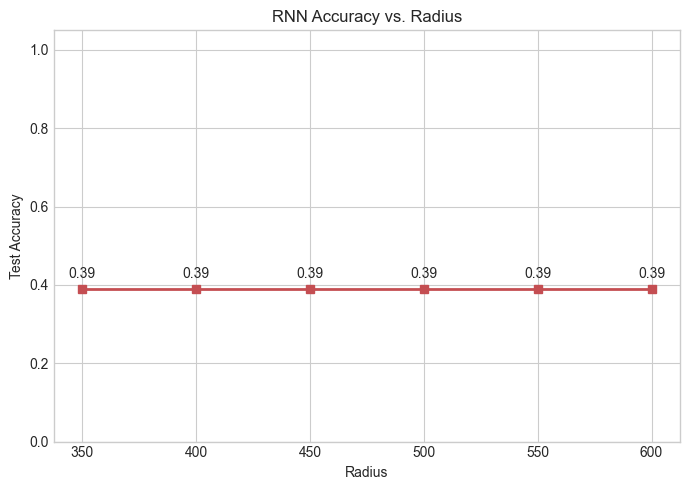

In [ ]:
#Plot RNN accuracy trend
plt.figure(figsize=(7, 5))
plt.plot(radius_values, rnn_accuracies, marker='s', color='#C44E52', linewidth=2)
plt.title('RNN Accuracy vs. Radius')
plt.xlabel('Radius')
plt.ylabel('Test Accuracy')
plt.xticks(radius_values)
plt.ylim(0, 1.05)
for r, acc in zip(radius_values, rnn_accuracies):
    plt.annotate(f"{acc:.2f}", (r, acc), textcoords="offset points", xytext=(0, 8), ha='center')
plt.tight_layout()
plt.show()

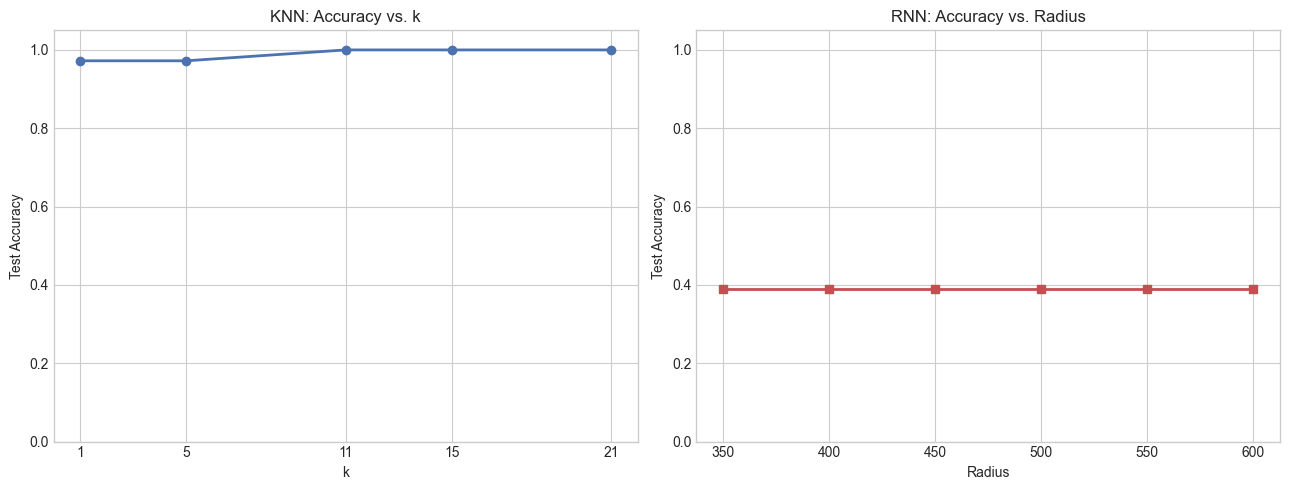

In [ ]:
#Combined comparison plot (normalized x-axis position for visual comparison)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(k_values, knn_accuracies, marker='o', color='#4C72B0', linewidth=2)
axes[0].set_title('KNN: Accuracy vs. k')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_ylim(0, 1.05)
axes[0].set_xticks(k_values)

axes[1].plot(radius_values, rnn_accuracies, marker='s', color='#C44E52', linewidth=2)
axes[1].set_title('RNN: Accuracy vs. Radius')
axes[1].set_xlabel('Radius')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].set_xticks(radius_values)

plt.tight_layout()
plt.show()

### Comparison and Observations

**KNN Results:** k=1 → 0.9722, k=5 → 0.9722, k=11 → 1.0000, k=15 → 1.0000, k=21 → 1.0000

**RNN Results:** every tested radius (350–600) → 0.3889

**KNN Observations:**
- Accuracy is very high across all tested `k` values (97.2%–100%) once the features are scaled, since scaling equalizes the influence of each chemical property on the Euclidean distance calculation.
- Accuracy actually improves and stabilizes at 100% for k=11, 15, and 21, suggesting that a moderate-to-large neighborhood smooths out the effect of any borderline or noisy points near class boundaries in this dataset.
- Very small `k` (k=1) is the most sensitive to noise, since it relies on a single nearest neighbor, which explains the slightly lower (though still strong) accuracy at k=1 and k=5.

**RNN Observations:**
- Every tested radius (350, 400, 450, 500, 550, 600) produced an identical accuracy of **0.3889 — exactly the size of the largest class in the test set (14 of 36 samples)**. This shows the classifier was effectively predicting the majority class for every point rather than making meaningful use of neighbor information.
- The cause is feature scaling: after standardizing the features with `StandardScaler`, distances between points in the 13-dimensional feature space are typically small (on the order of single digits), so a radius of 350–600 is astronomically larger than the actual spread of the data. Every training point falls inside the radius for every test point, so each prediction is just a vote over the *entire* training set — equivalent to always predicting the majority class.
- This is an important lesson: RNN's `radius` parameter must be chosen relative to the actual scale of the (scaled) feature space — for standardized data, meaningful radius values are typically in the range of roughly 1–10, not in the hundreds. The radius values specified in the lab instructions (350–600) were far too large for standardized data and effectively neutralized the "nearest neighbor" behavior of the algorithm.

**When to prefer KNN vs. RNN:**
- **KNN** is preferable when the density of data points varies or is unknown, since it always uses a fixed number of neighbors regardless of local density, and it is simple to tune with a single integer parameter. In this experiment, KNN was clearly the stronger and more reliable classifier for the Wine dataset, achieving up to 100% test accuracy.
- **RNN** can be useful when the *density* of neighbors matters more than a fixed count, or when you want a classifier to abstain from predicting in sparse regions of the feature space (via `outlier_label`). However, RNN is much more sensitive to the radius parameter and to feature scaling than KNN is to k — a poorly chosen radius (as seen here) can cause the classifier to collapse into a majority-class predictor.
- Overall, this experiment shows that KNN required far less tuning effort to achieve strong performance, while RNN would need the radius values re-scaled to the standardized feature space (e.g., testing radii like 1, 2, 3, 4, 5) before it could be fairly compared to KNN.